In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [ ]:
# 데이터 불러오기

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [ ]:
# 데이터 개요

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [ ]:
# 수치형 데이터 정보 요약

train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# 특정 컬럼의 평균값 확인

train['Age'].mean()

29.36158249158249

In [ ]:
# Age 특성의 결측치를 평균값으로 채워준다.

train['Age'].fillna(train['Age'].mean(), inplace = True)

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


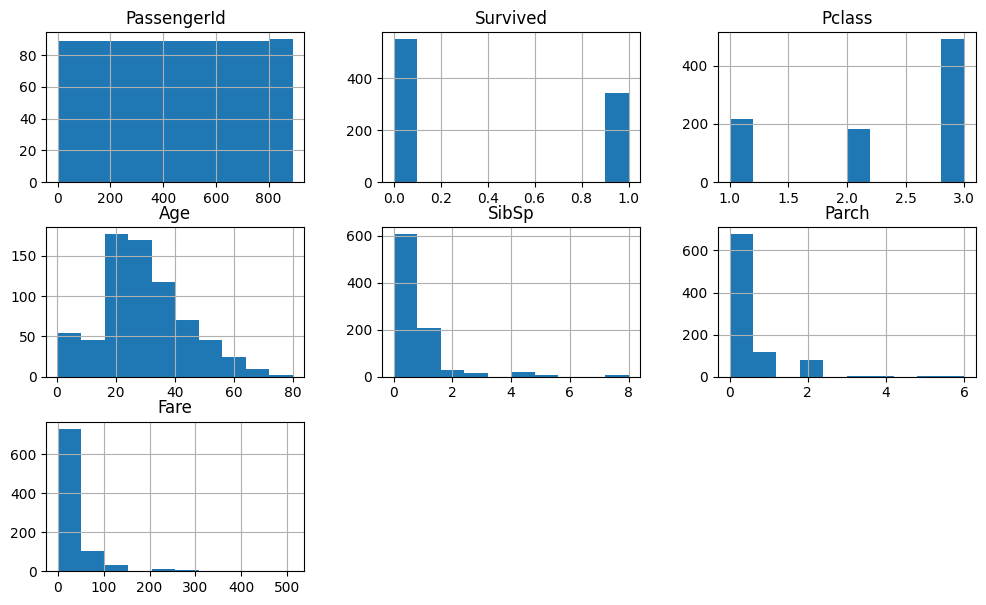

In [ ]:
# hist 메소드를 이용하여 데이터셋의 수치형 데이터 구성을 히스토그램으로 대략 알 수 있다.

train.hist(figsize = (12, 7))
plt.show()

In [ ]:
# 정규화

from sklearn.preprocessing import MinMaxScaler

scaler1 = MinMaxScaler()
scaler2 = MinMaxScaler(feature_range = (2, 3)) # 정규화 범위를 [2, 3] 으로 설정

scaled_1 = scaler1.fit_transform(train['Age'].values.reshape(-1, 1))
scaled_2 = scaler2.fit_transform(train['Age'].values.reshape(-1, 1))

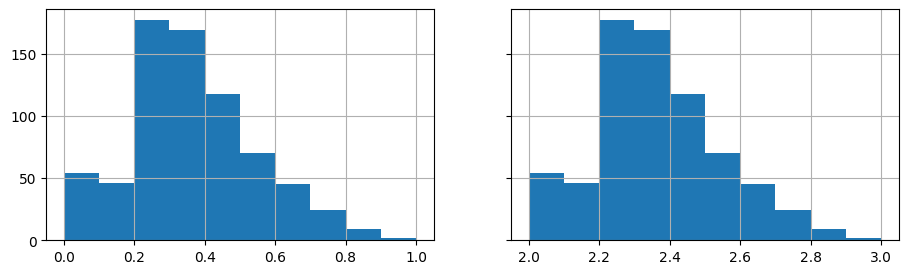

In [ ]:
# 정규화 결과 시각화

fig, axs = plt.subplots(ncols = 2, sharey = True, figsize = (11, 3))
axs = axs.flatten()

plt.sca(axs[0])
plt.hist(scaled_1)
plt.yticks([0, 50, 100, 150, 200])
plt.grid()

plt.sca(axs[1])
plt.hist(scaled_2)
plt.grid()

plt.show()

In [ ]:
# 표준화

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(train['Age'].values.reshape(-1, 1))

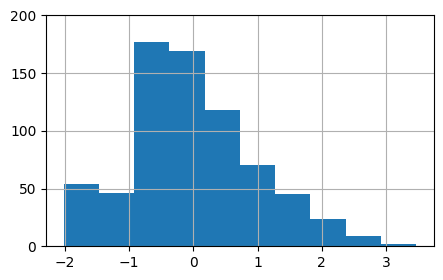

In [ ]:
# 표준화 결과 시각화

plt.figure(figsize = (5, 3))
plt.hist(scaled)
plt.grid()
plt.yticks([0, 50, 100, 150, 200])

plt.show()

In [ ]:
# 로그 변환

scaled = np.log(train['Fare'] + 1)

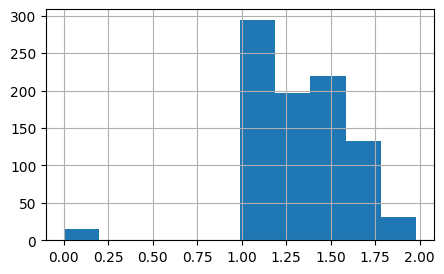

In [ ]:
# 로그 변환 후 시각화

plt.figure(figsize = (5, 3))
plt.hist(scaled)
plt.grid()

plt.show()

In [ ]:
# 특정 컬럼의 값의 빈도 수 확인

train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [ ]:
# Embarked 특성의 결측치를 최빈값인 S로 채워줌

train['Embarked'].fillna('S', inplace = True)

In [ ]:
# Embarked 특성의 처음 5개 값

train['Embarked'][:5]

0    S
1    C
2    S
3    S
4    S
Name: Embarked, dtype: object

In [ ]:
# 원 핫 인코딩을 적용한 경우 Embarked 특성의 처음 5개 값

pd.get_dummies(train['Embarked'], dtype = int).head()

,C,Q,S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1


In [78]:
# 레이블 인코딩

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

encoded = encoder.fit_transform(train['Embarked'].values)

In [80]:
encoded[:5]

array([2, 0, 2, 2, 2])